In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

In [11]:
df = pd.read_csv("netflix_titles.csv")
print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [12]:
print("Shape of Dataset:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape of Dataset:
(8807, 12)

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicate Rows:
0


In [14]:
print("""
1. The dataset contains Netflix Movies and TV Shows.
2. It includes information such as title, cast, director, country, release year and ratings.
3. The dataset contains both categorical and numerical features.
4. Some columns contain missing values.
5. The dataset can be used to analyze Netflix content trends and distribution.
""")


1. The dataset contains Netflix Movies and TV Shows.
2. It includes information such as title, cast, director, country, release year and ratings.
3. The dataset contains both categorical and numerical features.
4. Some columns contain missing values.
5. The dataset can be used to analyze Netflix content trends and distribution.



In [15]:
print("Missing Values Before Cleaning:")
print(df.isnull().sum())

Missing Values Before Cleaning:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [17]:
# Fill missing values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

# Clean and convert date column
df['date_added'] = df['date_added'].str.strip()

df['date_added'] = pd.to_datetime(
    df['date_added'],
    format='mixed',
    errors='coerce'
)

# Remove duplicates
df = df.drop_duplicates()

print("Cleaning Completed")

Cleaning Completed


In [18]:
print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64


In [19]:
print("Movies vs TV Shows")

print(df['type'].value_counts())

Movies vs TV Shows
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [20]:
print("Top 10 Countries")

print(df['country'].value_counts().head(10))

Top 10 Countries
country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


In [21]:
content_year = df['release_year'].value_counts().sort_index()

print(content_year.tail(20))

release_year
2002      51
2003      61
2004      64
2005      80
2006      96
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64


In [22]:
print(df['rating'].value_counts())

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [23]:
genres = df['listed_in'].str.split(', ').explode()

print(genres.value_counts().head(10))

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


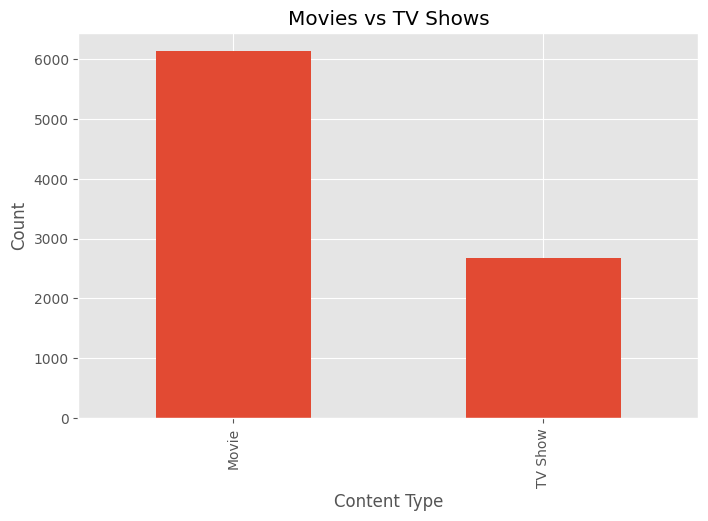

In [24]:
plt.figure(figsize=(8,5))

df['type'].value_counts().plot(kind='bar')

plt.title('Movies vs TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Count')

plt.show()

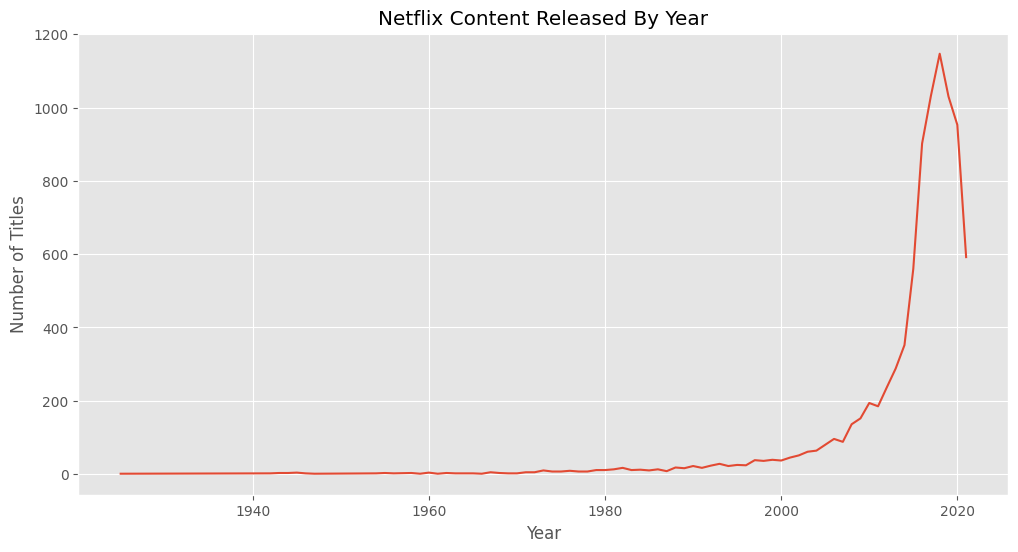

In [25]:
year_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))

plt.plot(year_counts.index, year_counts.values)

plt.title('Netflix Content Released By Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.show()

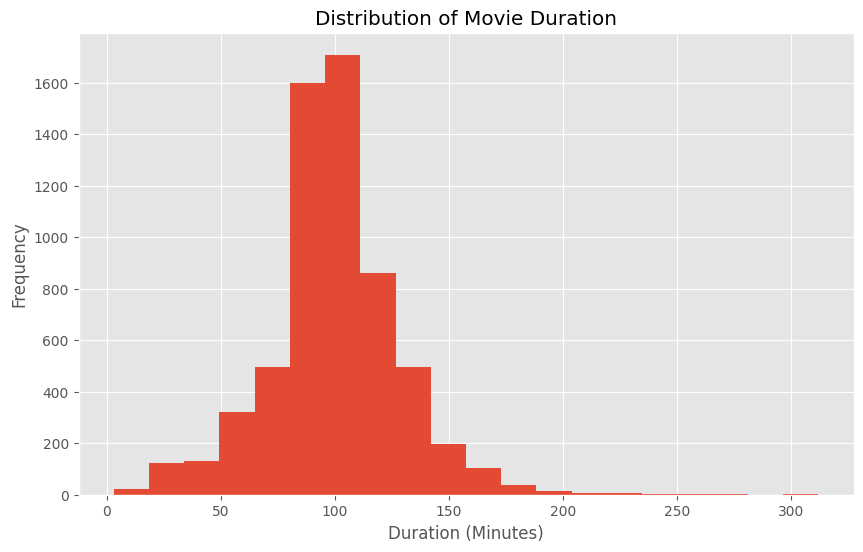

In [26]:
movies = df[df['type']=='Movie'].copy()

movies['duration'] = movies['duration'].str.replace(' min','')

movies['duration'] = pd.to_numeric(
    movies['duration'],
    errors='coerce'
)

plt.figure(figsize=(10,6))

plt.hist(
    movies['duration'].dropna(),
    bins=20
)

plt.title('Distribution of Movie Duration')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Frequency')

plt.show()

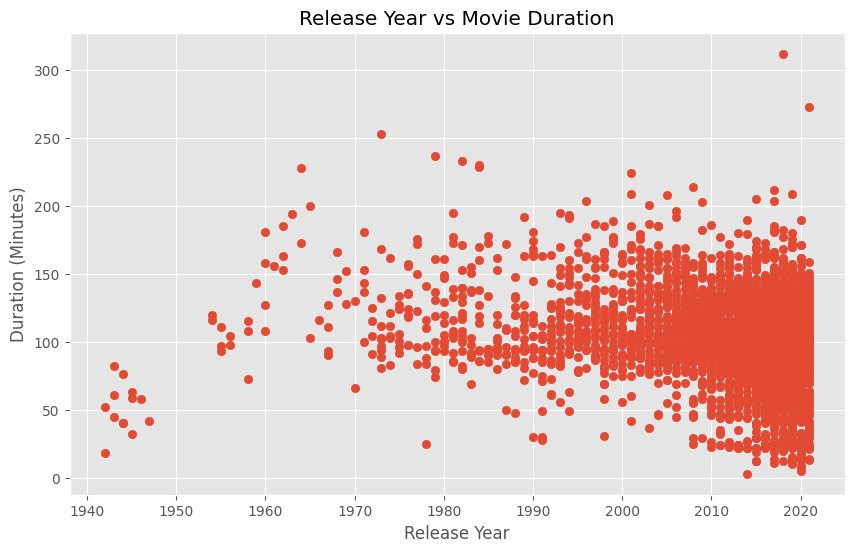

In [27]:
plt.figure(figsize=(10,6))

plt.scatter(
    movies['release_year'],
    movies['duration']
)

plt.title('Release Year vs Movie Duration')
plt.xlabel('Release Year')
plt.ylabel('Duration (Minutes)')

plt.show()

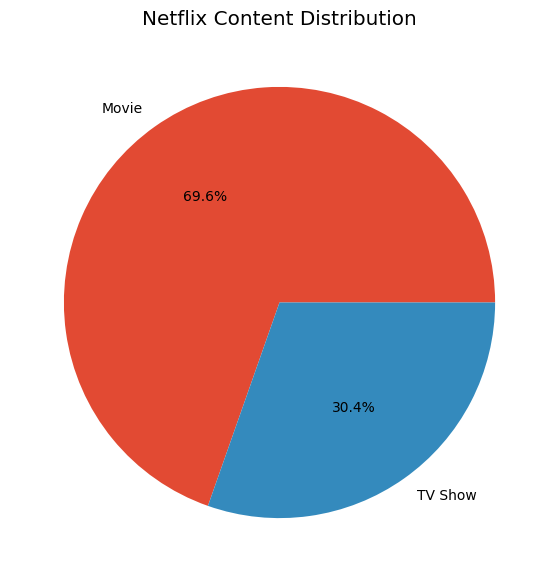

In [28]:
content_type = df['type'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    content_type,
    labels=content_type.index,
    autopct='%1.1f%%'
)

plt.title('Netflix Content Distribution')

plt.show()

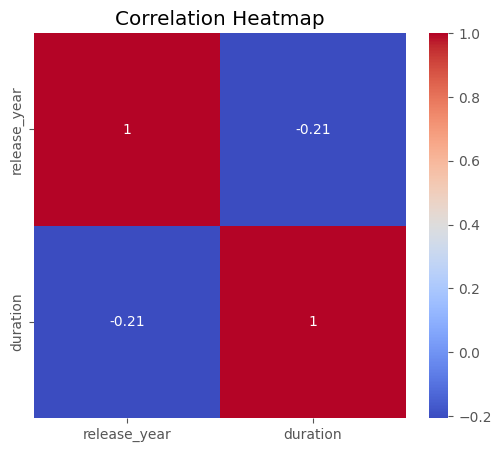

In [29]:
corr_data = movies[['release_year','duration']].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr_data,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

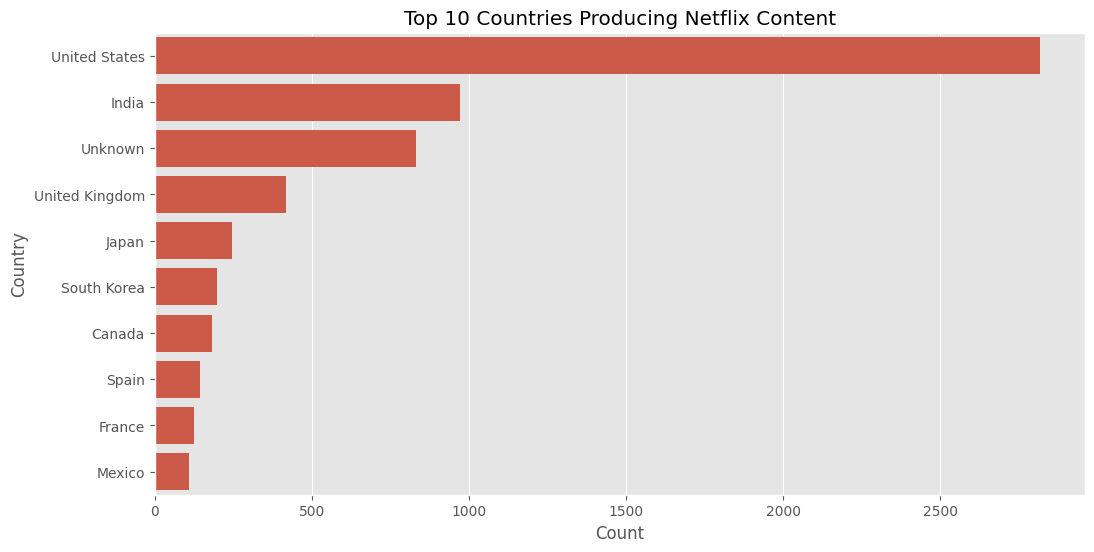

In [30]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Count')
plt.ylabel('Country')

plt.show()

In [31]:
print("""
INSIGHTS REPORT

1. Movies dominate Netflix content and significantly outnumber TV Shows.

2. The United States contributes the highest amount of content to Netflix.

3. Netflix content production increased rapidly after 2015.

4. Drama and International Movies are among the most popular genres.

5. Most Netflix movies have durations between 80 and 120 minutes.
""")


INSIGHTS REPORT

1. Movies dominate Netflix content and significantly outnumber TV Shows.

2. The United States contributes the highest amount of content to Netflix.

3. Netflix content production increased rapidly after 2015.

4. Drama and International Movies are among the most popular genres.

5. Most Netflix movies have durations between 80 and 120 minutes.

